In [29]:
#This notebook is about KNN algorithm.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df=pd.read_csv("health_risk_classification.csv")
df.head(10)

,bmi_score,blood_pressure_variation,activity_level_index,high_risk_flag
0,0.564223,0.652825,1.262925,1
1,-1.692569,2.981229,-0.180331,1
2,0.770383,0.400475,1.365806,1
3,2.135007,0.150832,3.084596,0
4,0.360342,1.026132,1.251574,1
5,1.626422,-0.458717,1.930796,0
6,0.401069,-1.264278,-0.364762,0
7,-3.429496,1.253978,-3.861862,1
8,-1.117292,2.146037,0.011042,1
9,1.620790,-0.501553,1.891660,0


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   bmi_score                 1000 non-null   float64
 1   blood_pressure_variation  1000 non-null   float64
 2   activity_level_index      1000 non-null   float64
 3   high_risk_flag            1000 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 31.4 KB


In [32]:
df.describe()

,bmi_score,blood_pressure_variation,activity_level_index,high_risk_flag
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.023702,0.016769,-0.020771,0.498000
std,1.203694,1.268761,1.392738,0.500246
min,-4.743951,-2.587178,-4.999018,0.000000
25%,-0.796655,-0.981320,-1.057938,0.000000
50%,0.142105,-0.317137,0.204506,0.000000
75%,0.956225,1.017388,1.061181,1.000000
max,2.321480,3.954873,3.477210,1.000000


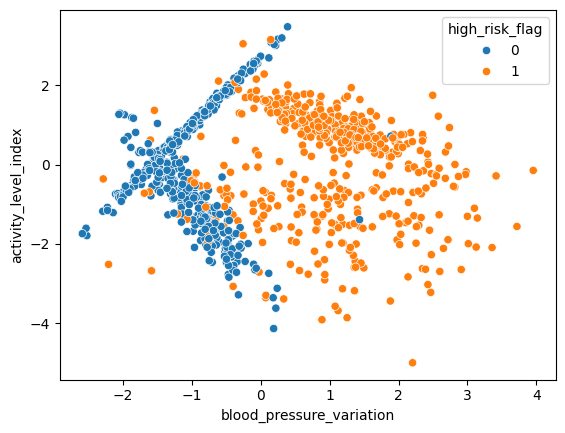

In [33]:
sns.scatterplot(x=df["blood_pressure_variation"], y=df["activity_level_index"], hue=df["high_risk_flag"])
plt.show()

In [34]:
df["high_risk_flag"].value_counts()

high_risk_flag
0    502
1    498
Name: count, dtype: int64

In [35]:
X=df.drop("high_risk_flag", axis=1)
y=df["high_risk_flag"]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=34)

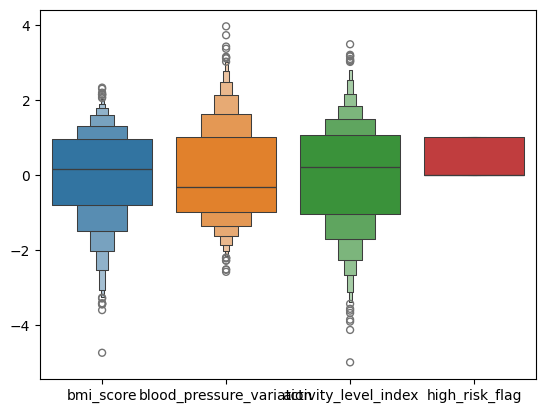

In [36]:
sns.boxenplot(df)
plt.show()

In [37]:
#The data is already scaled. So, we do not need to scale the data. If we want to scale the data, we can use StandardScaler.
#from sklearn.preprocessing import StandardScaler
#scaler=StandardScaler()    
#X_train_scaled=scaler.fit_trasnform(X_train)
#X_train_scaled=scaler.transform(X_test)       

In [38]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5, algorithm="auto", weights="uniform")
knn.fit(X_train, y_train)
y_pred=knn.predict(X_test)

In [39]:
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
print("Confusion Matrix:")
print(confusion_matrix(y_pred, y_test))
print("Accuracy:", accuracy_score(y_pred, y_test))
print("classification_report:\n", classification_report(y_pred, y_test))

Confusion Matrix:
[[104   9]
 [  1 136]]
Accuracy: 0.96
classification_report:
               precision    recall  f1-score   support

           0       0.99      0.92      0.95       113
           1       0.94      0.99      0.96       137

    accuracy                           0.96       250
   macro avg       0.96      0.96      0.96       250
weighted avg       0.96      0.96      0.96       250



In [40]:
knn2=KNeighborsClassifier(n_neighbors=5, algorithm="kd_tree", weights="uniform")
knn2.fit(X_train, y_train)
y_pred2=knn2.predict(X_test)
print("Confusion Matrix:")
print(confusion_matrix(y_pred2, y_test))
print("Accuracy:", accuracy_score(y_pred2, y_test))
print("classification_report:\n", classification_report(y_pred2, y_test))


Confusion Matrix:
[[104   9]
 [  1 136]]
Accuracy: 0.96
classification_report:
               precision    recall  f1-score   support

           0       0.99      0.92      0.95       113
           1       0.94      0.99      0.96       137

    accuracy                           0.96       250
   macro avg       0.96      0.96      0.96       250
weighted avg       0.96      0.96      0.96       250



In [41]:
knn3=KNeighborsClassifier(n_neighbors=5, algorithm="brute", weights="uniform")
knn3.fit(X_train, y_train)
y_pred3=knn3.predict(X_test)
print("Confusion Matrix:")
print(confusion_matrix(y_pred3, y_test))
print("Accuracy:", accuracy_score(y_pred3, y_test))
print("classification_report:\n", classification_report(y_pred3, y_test))


Confusion Matrix:
[[104   9]
 [  1 136]]
Accuracy: 0.96
classification_report:
               precision    recall  f1-score   support

           0       0.99      0.92      0.95       113
           1       0.94      0.99      0.96       137

    accuracy                           0.96       250
   macro avg       0.96      0.96      0.96       250
weighted avg       0.96      0.96      0.96       250



In [42]:
knn4=KNeighborsClassifier(n_neighbors=3, algorithm="kd_tree", weights="uniform")
knn4.fit(X_train, y_train)
y_pred4=knn4.predict(X_test)
print("Confusion Matrix:")
print(confusion_matrix(y_pred4, y_test))
print("Accuracy:", accuracy_score(y_pred4, y_test))
print("classification_report:\n", classification_report(y_pred4, y_test))

Confusion Matrix:
[[103   9]
 [  2 136]]
Accuracy: 0.956
classification_report:
               precision    recall  f1-score   support

           0       0.98      0.92      0.95       112
           1       0.94      0.99      0.96       138

    accuracy                           0.96       250
   macro avg       0.96      0.95      0.96       250
weighted avg       0.96      0.96      0.96       250

